In [7]:
import numpy as np
import matplotlib.pyplot as plt
import RCP_analysis as rcp
from pathlib import Path

%matplotlib inline

# Config
# rsa params
Z_SCORE_FEATURES = True          # z-score channels across trials before distances
SAVE_SVG = True                  # save under figures/rsa_from_peristim/
MIN_TRIALS_PER_COND = 4          # drop conditions (NPZ files) with fewer trials
MIN_VALID_FEATURES = 2           # trial must have at least this many finite channels
FILE_SLICE = slice(None)         # e.g., slice(None, 10) to cap number of NPZs

# default params
MOVE_BASE_WIN_MS    = (-800.0, -500.0)  # pre-movement baseline window
MOVE_RESP_WIN_MS    = (0.0,  300.0)  # movement response window
STIM_WIN_MS         = (105.0,  150.0)   # window checked for stim-evoked channel responses

# Paths
REPO_ROOT = Path().resolve().parents[2]
PARAMS = rcp.load_experiment_params(
    REPO_ROOT / "config" / "params.yaml",
    repo_root=REPO_ROOT,
)
SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
FIG_DIR = OUT_BASE / "figures" / "rsa_from_peristim"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
cond_label_extras = {
    "Baseline": "Control reaches",
    11: "1 pulse",
    12: "2 pulses",
    14: "4 pulses",
    15: "8 pulses",
    16: "20 pulses",
    17: "40 pulses",
}

In [5]:
rcp.run_rsa(source="NPRW",
              target="target_A",
              poststim_win_ms=(-500.0, -100.0),
              cond_label_extras=cond_label_extras,
              vmin=-0.75, vmax=0.75,
              skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
              cond_order=["Baseline", 10, 5, 11, 7],
              channel_criterion=None,
              )


[run] probe=NPRW  target=target_A  poststim=-500.0--100.0ms
[run] baseline: ['BR_001_target_A.npz', 'BR_018_target_A.npz', 'BR_026_target_A.npz']
[run][skip] skip_conds=18,19,20,21,22,23,24,25,26,27,28,29,30,31
[run] baseline (after skip_conds): ['BR_001_target_A.npz']  (dropped: ['BR_018_target_A.npz', 'BR_026_target_A.npz'])
[rsa-all-ch]       figure saved  n=80   channels=128  figures/rsa_from_peristim/target_A/RSA_NPRW_all-ch_criterion_poststim-500--100.svg


In [32]:
ctrl = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "control_reaches" / "target_A" / "peristim__NRR_RW022_260311_135426__BR_001_target_A.npz",
    allow_pickle=True)

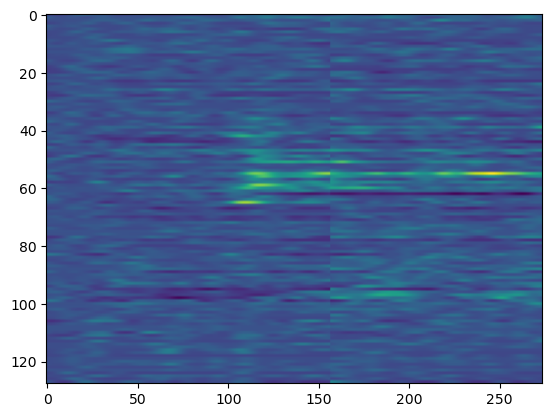

In [33]:
plt.imshow(ctrl['UA_rates_zeroed'][0, :, :], aspect="auto", origin="upper")

In [37]:
stim_16 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_A" / "peristim__NRR_RW022_260311_143246__BR_016_target_A.npz",
    allow_pickle=True)

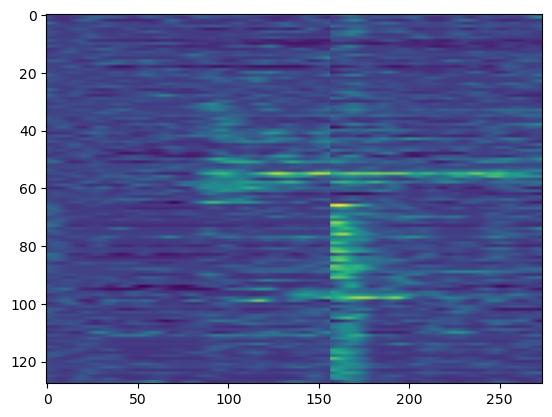

In [38]:
plt.imshow(stim_16['UA_rates_zeroed'][0, :, :], aspect="auto", origin="upper")

In [39]:
stim_17 = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_A" / "peristim__NRR_RW022_260311_143434__BR_017_target_A.npz",
    allow_pickle=True)

In [40]:
stim_17['UA_rates_zeroed'].shape

(12, 128, 274)

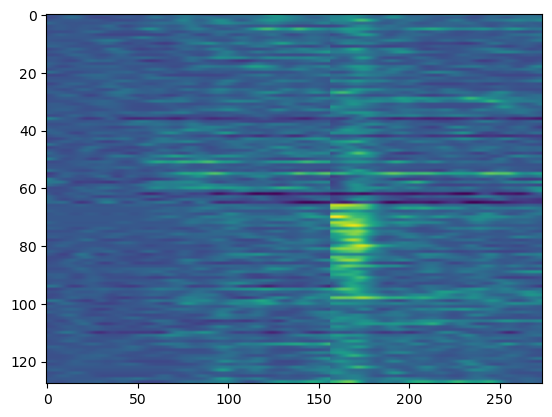

In [ ]:
plt.imshow(stim_17['UA_rates_zeroed'][0, :, :], aspect="auto", origin="upper")

In [5]:
rcp.run_rsa(
    source="NPRW",
    target="target_A",
    poststim_win_ms=(5.0, 50.0),
    channel_criterion=("movement", "stim", "union", "intersection", None),
    cond_label_extras=cond_label_extras,
    vmin=-0.75, vmax=0.75,
    skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
    cond_order=["Baseline", 11, 12, 14, 15, 16, 17],
    debug_masks=True,
)


[run] probe=NPRW  target=target_A  poststim=5.0-50.0ms
[run] baseline: ['BR_001_target_A.npz', 'BR_018_target_A.npz', 'BR_026_target_A.npz']
[run][skip] skip_conds=18,19,20,21,22,23,24,25,26,27,28,29,30,31
[run] baseline (after skip_conds): ['BR_001_target_A.npz']  (dropped: ['BR_018_target_A.npz', 'BR_026_target_A.npz'])
[move] 24/128 channels pass movement criterion
[move][debug-plot] wrote figures/rsa_from_peristim/target_A/debug_NPRW_movement_criterion_baseline-800--500movement0-300.png
[stim] ctrl pool: 17 control trials
[stim] 8/128 pass for BR_011_target_A.npz
[stim] 10/128 pass for BR_012_target_A.npz
[stim] 11/128 pass for BR_014_target_A.npz
[stim] 16/128 pass for BR_015_target_A.npz
[stim] 13/128 pass for BR_016_target_A.npz
[stim] 13/128 pass for BR_017_target_A.npz
[stim][union] 22/128 channels passing stim criterion
[stim][debug-plot] saved figures/rsa_from_peristim/target_A/debug_NPRW_stim_criterion_poststim105-150.png
[rsa-movement]     figure saved  n=80   channels=24

In [8]:
rcp.run_rsa(
    source="UA",
    target="target_A",
    poststim_win_ms=(5.0, 50.0),
    channel_criterion=("movement", "stim", "union", "intersection", None),
    cond_label_extras=cond_label_extras,
    vmin=-0.75, vmax=0.75,
    skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
    cond_order=["Baseline", 11, 12, 14, 15, 16, 17],
    debug_masks=True,
)


[run] probe=UA  target=target_A  poststim=5.0-50.0ms
[run] baseline: ['BR_001_target_A.npz', 'BR_018_target_A.npz', 'BR_026_target_A.npz']
[run][skip] skip_conds=18,19,20,21,22,23,24,25,26,27,28,29,30,31
[run] baseline (after skip_conds): ['BR_001_target_A.npz']  (dropped: ['BR_018_target_A.npz', 'BR_026_target_A.npz'])
[move] 39/128 channels pass movement criterion
[move][debug-plot] wrote figures/rsa_from_peristim/target_A/debug_UA_movement_criterion_baseline-800--500movement0-300.png
[stim] ctrl pool: 17 control trials
[stim] 2/128 pass for BR_011_target_A.npz
[stim] 1/128 pass for BR_012_target_A.npz
[stim] 1/128 pass for BR_014_target_A.npz
[stim] 6/128 pass for BR_015_target_A.npz
[stim] 5/128 pass for BR_016_target_A.npz
[stim] 66/128 pass for BR_017_target_A.npz
[stim][union] 68/128 channels passing stim criterion
[stim][debug-plot] saved figures/rsa_from_peristim/target_A/debug_UA_stim_criterion_poststim105-150.png
[rsa-movement]     figure saved  n=80   channels=39   figures